# Análisis exploratorio del dataset de test de PROFE 2025

Este dataset ha sido creado por Anna-María Winkler como parte de su TFM *From human subjectivity to algorithmic objectivity: Automatic Reading Comprehension Assessment in Spanish as a Foreign Language* para probar sus soluciones para la tarea [PROFE 2025](https://sites.google.com/view/profe2026).

Dado que el dataset IC-UNED-RC-ES no está disponible de forma pública, tomaré este conjunto de datos como punto de partida para evaluar las distintas soluciones propuestas a lo largo del trabajo. Este contiene ejercicios de distintos niveles para la tarea de *multiple choice*. A continuación se muestra un análisis más detallado.

En primer lugar, los exámenes están organizados por nivel (A1, A2, B1...), cada uno con una serie de ejercicios que, a su vez, pueden contener una o varias preguntas.

Nivel > Ejercicios > Preguntas

## Librerías necesarias

In [1]:
import pandas as pd
import json
import matplotlib.pyplot as plt

## Distribución de exámenes, ejercicios y preguntas por nivel

La letra 'E' seguida del nivel del examen significa 'Escolar', lo que indica que el examen está orientado a estudiantes, mientras que el resto están pensados para un público más adulto. No obstante, el nivel del examen es el mismo por lo que no hay una diferencia significativa.

Analizando la distribución de los exámenes por nivel, vemos que en total tenemos 136 exámenes, entre los que predominan los de niveles intermedios (A2, B2 y B2). Los niveles A1 y C2 tienen unos 18 exámenes cada uno mientras que para el nivel C1 apenas se dispone de 3 exámenes.

Número total de exámenes:
136


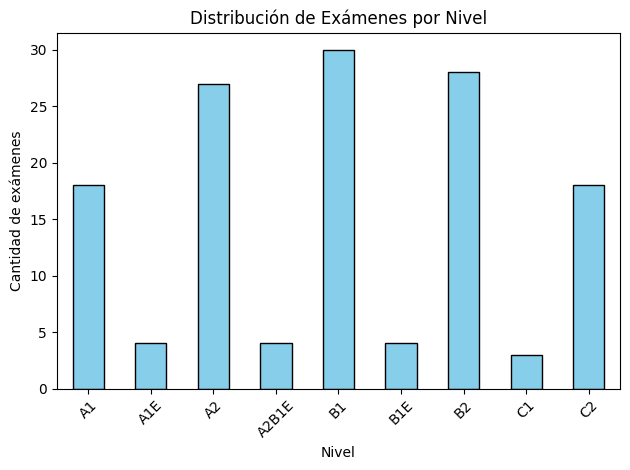

Distribución de exámenes por nivel:
level
A1       18
A1E       4
A2       27
A2B1E     4
B1       30
B1E       4
B2       28
C1        3
C2       18
Name: count, dtype: int64


In [ ]:
# Carga del fichero
with open('./data/multiple_choice.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

# Obtener dataframe de exámenes
df_exams = pd.DataFrame(data['exams'])

# Distribución del campo level
level_distribution = df_exams['level'].value_counts().sort_index()

print("Número total de exámenes:")
print(len(df_exams))

# Gráfica
level_distribution.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Distribución de Exámenes por Nivel')
plt.xlabel('Nivel')
plt.ylabel('Cantidad de exámenes')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Distribución de exámenes por nivel:")
print(level_distribution)

A continuación se muestra un desglose del número de ejercicios y preguntas disponibles para cada uno de los niveles. Podemos comprobar que sigue habiendo un dominio claro de los niveles intermedios. Para los niveles A1 y C1 la representación es bastante minoritaria pero podrá darnos una idea algo menos representativa del comportamiento de los modelos con estos niveles y, por último, el nivel C2 sí dispone de un número considerable de preguntas, por lo que podremos comprobar su dominio del idioma con el nivel más avanzado.

Resumen de datos por nivel:
       Exámenes  Ejercicios  Preguntas
Nivel                                 
A1           18          18         72
A1E           4           8         48
A2           27         245        488
A2B1E         4           4         24
B1           30         206        488
B1E           4          36         80
B2           28          97        306
C1            3           6         36
C2           18          54        162
TOTAL       136         674       1704


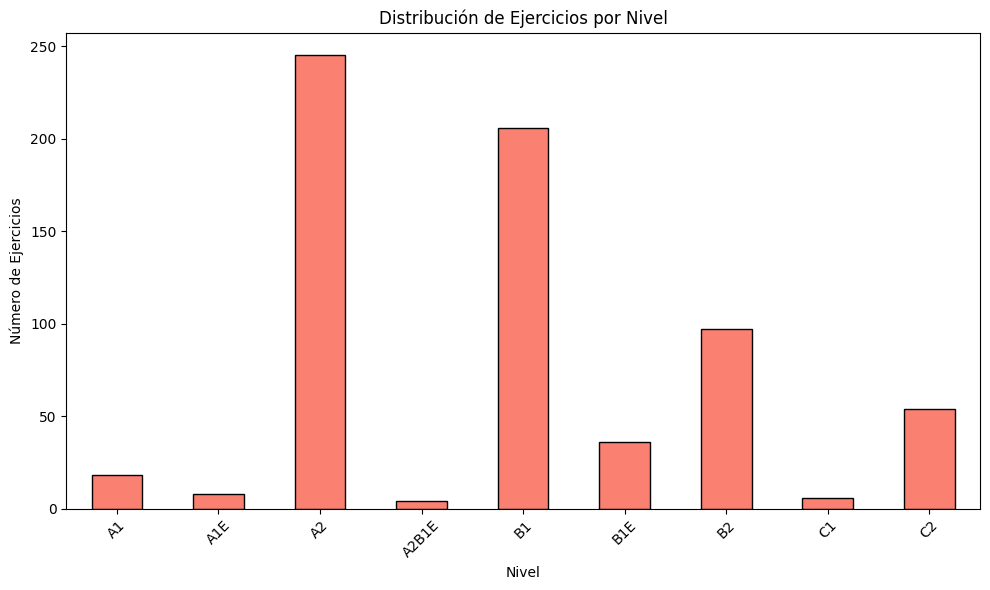

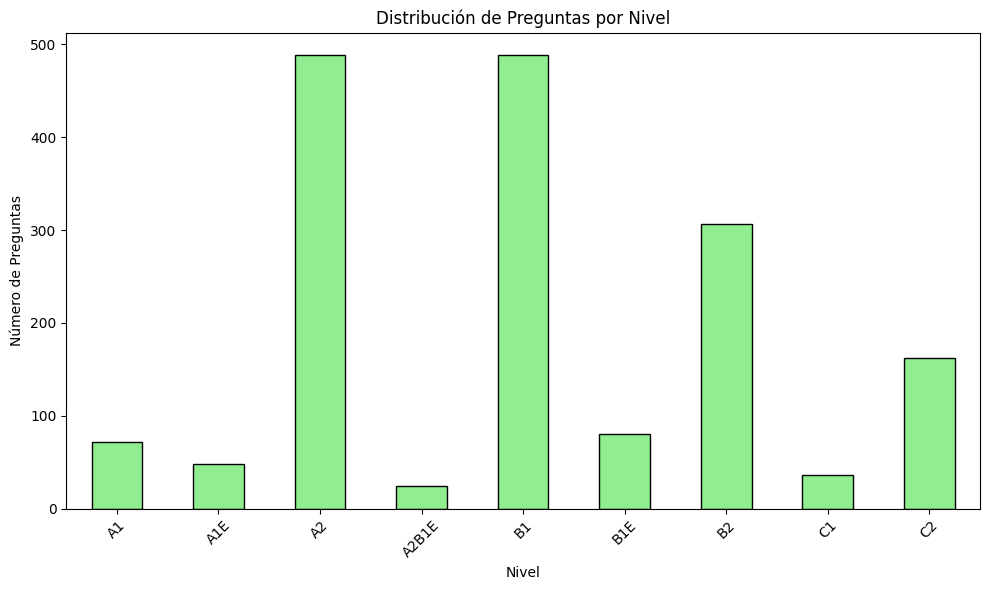

In [ ]:

exams_info = []

for exam in data['exams']:
    level = exam['level']
    num_exercises = len(exam['exercises'])
    num_questions = 0
    
    # Contar preguntas dentro de cada uno de los ejercicios
    for exercise in exam['exercises']:
        exercise_content = exercise.get('exercise', {})
        questions = exercise_content.get('questions', [])
        num_questions += len(questions)
    
    exams_info.append({
        'Nivel': level,
        'Exámenes': 1,
        'Ejercicios': num_exercises,
        'Preguntas': num_questions
    })

# Agrupar por nivel para ver los totales
df_summary = pd.DataFrame(exams_info).groupby('Nivel').sum()

# Ordenar niveles para mostrar las gráficas
exams_level_order = ['A1', 'A1E', 'A2', 'A2B1E', 'B1', 'B1E', 'B2', 'C1', 'C2']
existing_levels = [l for l in exams_level_order if l in df_summary.index]
df_exams_info = df_summary.reindex(existing_levels)

# Tabla comparativa Exámenes - Ejercicios - Preguntas
df_with_total = df_exams_info.copy()
df_with_total.loc['TOTAL'] = df_with_total.sum()
print("Resumen de datos por nivel:")
print(df_with_total)

# Gráfica distribución de ejercicios por nivel
plt.figure(figsize=(10, 6))
df_exams_info['Ejercicios'].plot(kind='bar', color='salmon', edgecolor='black')
plt.title('Distribución de Ejercicios por Nivel')
plt.xlabel('Nivel')
plt.ylabel('Número de Ejercicios')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Gráfica distribución de preguntas por nivel
plt.figure(figsize=(10, 6))
df_exams_info['Preguntas'].plot(kind='bar', color='lightgreen', edgecolor='black')
plt.title('Distribución de Preguntas por Nivel')
plt.xlabel('Nivel')
plt.ylabel('Número de Preguntas')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Ejemplos de distintos textos

A continuación se muestra un ejemplo de un texto para cada nivel de examen. 

Puede verse que para el texto de nivel A1 hay 4 posibles de respuesta mientras que el resto tienen 3. En principio no debería suponer ningún problema puesto que a los modelos se les pedirá seleccionar la opción correcta de entre las posibles. Además, como es lógico, la complejidad de los texts va aumentando tanto en su contenido como en su extensión, por lo que habrá que ver cómo se comportan los modelos con las distintas técnicas para los distintos niveles y cuáles son capaces de comprender y responder mejor.

In [28]:
examples = {}

# Orden de los exámenes por nivel
exams_level_order = ['A1', 'A1E', 'A2', 'A2B1E', 'B1', 'B1E', 'B2', 'C1', 'C2']

for exam in data['exams']:
    level = exam['level']
    
    if level in examples:
        continue
    
    if exam.get('exercises'):
        exercise = exam['exercises'][0].get('exercise', {})
        text = exercise.get('text', 'Sin texto disponible')
        
        if exercise.get('questions'):
            question = exercise['questions'][0]
            examples[level] = {
                'text': text,
                'question': question.get('text', 'Sin pregunta'),
                'options': question.get('options', [])
            }

print("=== EJEMPLO DE EXAMEN POR NIVEL ===\n")

for level in exams_level_order:
    if level in examples:
        exercise = examples[level]
        
        print(f"NIVEL: {level}")
        print("-" * 40)
        
        print(f"TEXTO:")
        print(exercise['text'])
        
        print(f"\nPREGUNTA: {exercise['question']}")
        print("OPCIONES:")
        
        for opt in exercise['options']:
            letra = opt.get('optionId', '?')
            contenido_opcion = opt.get('text', '')
            print(f"  {letra}) {contenido_opcion}")
            
        print("\n" + "="*70 + "\n")

=== EJEMPLO DE EXAMEN POR NIVEL ===

NIVEL: A1
----------------------------------------
TEXTO:
Duerida ALicia -
¿Qué tal estás? ¿Te gusta tu nuevo trabajo en Barcelona? Yo en Madrid
estoy muy bien. Tengo que darte buenas noticias. La próxima semana voy a
Barcelona con mi hija Celia, ¿ la recuerdas? Va a hacer este verano un curso
sobre cine allí. El curso es de un mes y empieza el 15 de agosto. Sólo tiene clases
por las mañanas, de nueve a una. Está muy contenta porque puede vistar los
monumentos de Gaudi, le encanta el arte.
Voy a ir con Luis. Queremos estar con Celia durante la primera semana
porque es la primera vez que viaja sola. Tengo muchas ganas de verte y visitar
la ciudad contigo. Luis prefere ir a la playa porque a ál no le gusta mucho
caminar y quiere descansar unos días.
Hemos reservado un hotel muy cerca de tu casa, en el contro. Está al lado de un
restaurante nuevo muy caro. Hemos comido alll una vez ¿te acuerdas? Tiene
una terraza muy grande.
Llegamos este sábado por la